In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

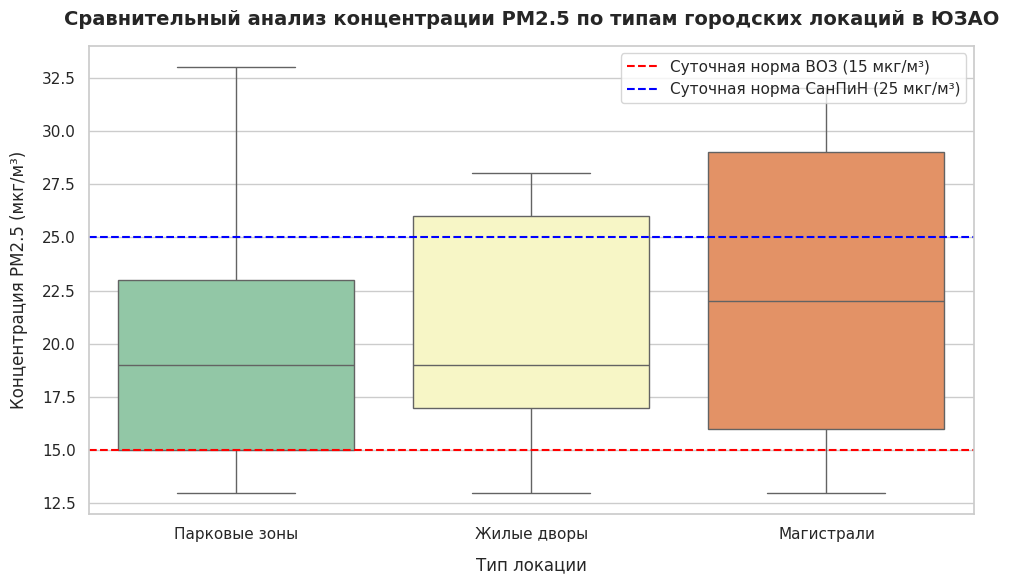

In [3]:
df_parks = pd.read_csv('all_parks_combined.csv')
df_dvors = pd.read_csv('all_dvor_combined.csv')       # Укажите ваше имя файла для дворов
df_highways = pd.read_csv('all_magistral_combined.csv') # Укажите ваше имя файла для магистралей

# 2. Явно добавляем колонку с типом локации в каждый датафрейм
df_parks['location_type'] = 'Парковые зоны'
df_dvors['location_type'] = 'Жилые дворы'
df_highways['location_type'] = 'Магистрали'

# 3. Склеиваем их вертикально друг под друга в один общий датафрейм
plot_types_df = pd.concat([df_parks, df_dvors, df_highways], ignore_index=True)

# 4. Строим график (код идентичен прошлому шагу)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=plot_types_df,
    x='location_type',
    y='PM2.5',
    hue='location_type',
    palette='Spectral_r', # Магистрали уйдут в красный спектр, парки — в зеленый
    legend=False
)

plt.title('Сравнительный анализ концентрации PM2.5 по типам городских локаций в ЮЗАО', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Тип локации', fontsize=12, labelpad=10)
plt.ylabel('Концентрация PM2.5 (мкг/м³)', fontsize=12, labelpad=10)

plt.axhline(y=15, color='red', linestyle='--', linewidth=1.5, label='Суточная норма ВОЗ (15 мкг/м³)')
plt.axhline(y=25, color='blue', linestyle='--', linewidth=1.5, label='Суточная норма CaнПиН (25 мкг/м³)')
plt.legend(loc='upper right', frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig('location_types_from_separate_files.png', dpi=300)
plt.show()